# Exercícios — Capítulo 6: Processadores

**Livro:** *Introdução à Organização de Computadores* — Mário A. Monteiro, 5ª edição

Questões resolvidas: **1, 2, 3, 5, 6, 7, 8, 9, 11, 15, 18 e 22**.

Cada questão traz o recorte (print) do enunciado retirado do capítulo, seguido da resolução comentada.

---

## Questão 1 — Funções básicas da UCP e seus componentes

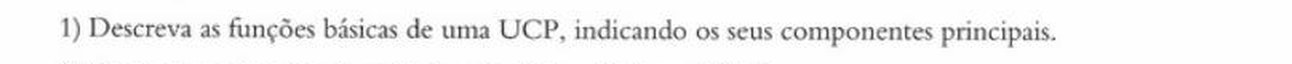

**Resolução**

A UCP (Unidade Central de Processamento) tem **duas funções básicas**:

1. **Função de processamento** — realizar efetivamente as operações sobre os dados: operações aritméticas (soma, subtração etc.), lógicas (E, OU, XOR, complemento), deslocamentos, comparações e movimentação de dados.
2. **Função de controle** — buscar cada instrução na memória principal, interpretá-la (decodificar) e comandar, na sequência e nos instantes corretos, todos os componentes envolvidos na sua execução.

**Componentes principais**, organizados por área:

| Área | Componente | Papel |
|---|---|---|
| Processamento | **UAL (ULA)** | executa as operações aritméticas e lógicas |
| Processamento | **ACC / registradores de dados** | guardam operandos e resultados |
| Controle | **UC (Unidade de Controle)** | gera os sinais de controle de cada etapa do ciclo de instrução |
| Controle | **CI (Contador de Instrução / PC)** | endereço da próxima instrução |
| Controle | **RI (Registrador de Instrução)** | armazena a instrução em execução |
| Controle | **Decodificador** | identifica qual instrução está no RI |
| Controle | **Relógio (clock)** | sincroniza todas as operações |
| Interface com a MP | **REM (MAR)** e **RDM (MBR)** | registradores de endereço e de dados para comunicação com a memória, via barramentos |


---

## Questão 2 — Funções da UAL

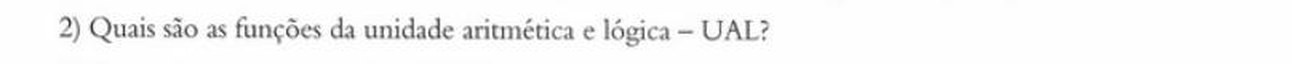

**Resolução**

A **UAL (Unidade Aritmética e Lógica)** é o dispositivo da área de processamento que **executa de fato as operações** indicadas pelo código de operação das instruções:

- **Operações aritméticas**: soma, subtração (e, conforme o processador, multiplicação, divisão, incremento/decremento);
- **Operações lógicas**: E (AND), OU (OR), OU exclusivo (XOR), complementação (NOT);
- **Deslocamentos** (shifts) e **comparações**.

Ela recebe os operandos vindos dos registradores (ou da memória, via RDM), produz o resultado — tipicamente devolvido a um registrador, como o ACC — e sinaliza condições do resultado (zero, negativo, "vai-um"/carry, overflow) usadas em desvios condicionais. A UAL **não decide nada**: quem determina qual operação ela realiza, e quando, é a unidade de controle.


---

## Questão 3 — O que é o ACC

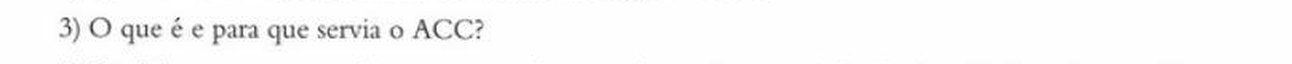

**Resolução**

**ACC = Acumulador**, um registrador da área de processamento da UCP, ligado diretamente à UAL.

**Para que servia:** nas máquinas de um operando explícito, o ACC **acumulava** um dos operandos e, ao final, **recebia o resultado** da operação realizada pela UAL — daí o nome. Por exemplo, uma instrução `ADD Op.` fazia:

$$ACC \leftarrow ACC + (Op.)$$

**Vantagem:** guardar operandos intermediários e resultados dentro da própria UCP evita acessos repetidos à memória principal (muito mais lenta), acelerando o processamento e encurtando as instruções (um operando fica implícito). Nos processadores atuais o conceito foi generalizado: em vez de um único ACC, há um **banco de registradores de dados** (R0, R1, …) com a mesma finalidade.


---

## Questão 5 — Funções da Unidade de Controle

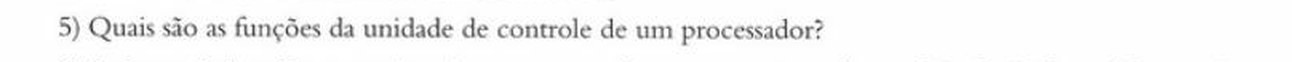

**Resolução**

A **Unidade de Controle (UC)** é responsável por comandar todo o **ciclo de instrução**. Suas funções:

1. **Busca da instrução** (fetch): transferir o endereço do CI para o REM, acionar a leitura da MP e levar a instrução do RDM para o RI;
2. **Interpretação/decodificação**: identificar, pelo código de operação, qual instrução será executada;
3. **Busca dos operandos**, quando a instrução referencia dados na memória;
4. **Execução**: emitir, na sequência e nos instantes corretos (sincronizados pelo relógio), os **sinais de controle** que acionam a UAL, os registradores, a memória e os barramentos;
5. **Armazenamento do resultado** e atualização do CI para a próxima instrução;
6. **Atendimento de interrupções**.

Em resumo: a UC não processa dados — ela **rege** os demais componentes, como um maestro, garantindo que cada etapa ocorra na ordem devida.


---

## Questão 6 — CI × REM: tamanhos diferentes?

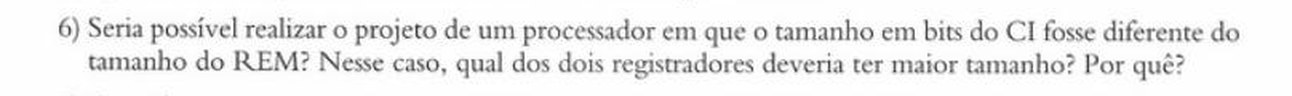

**Resolução**

**Sim, seria possível** — nada obriga os dois registradores a terem a mesma largura, embora ambos armazenem endereços da MP.

**Qual deveria ser maior? O REM.** Justificativa:

- O **REM** precisa ser capaz de armazenar **qualquer endereço** da memória, pois por ele passam tanto os endereços de **instruções** quanto os de **dados** (todo acesso à MP usa o REM). Sua largura define/acompanha o barramento de endereços;
- O **CI** armazena apenas endereços de **instruções**. Se o projeto restringisse a área de programas a uma **parte** da memória (por exemplo, os primeiros 2ᵏ endereços), o CI poderia ter menos bits que o REM.

O contrário (CI maior que o REM) **não faria sentido**: no início de todo ciclo de instrução o conteúdo do CI é copiado para o REM (CI → REM); um endereço gerado pelo CI que não coubesse no REM jamais poderia ser usado para acessar a memória.


---

## Questão 7 — Incremento do CI com instruções de tamanho variável

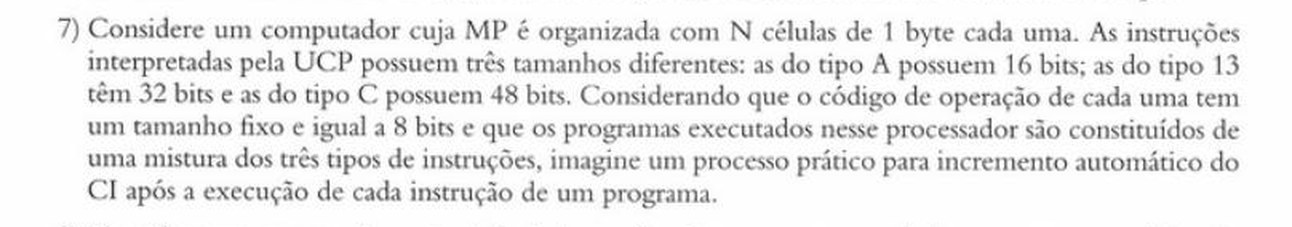

**Resolução**

Dados: células de 1 byte; instruções tipo **A = 16 bits (2 células)**, **B = 32 bits (4 células)**, **C = 48 bits (6 células)**; código de operação **fixo de 8 bits (1 célula)**, sempre no início da instrução.

**Processo prático:** como o C.Op. tem tamanho fixo e identifica univocamente cada instrução, ele identifica também o **tipo** — e, portanto, o **tamanho total** dela. Assim, o incremento do CI passa a ser **variável e decidido após a decodificação**:

1. A UC busca a célula apontada pelo CI — ela contém o **C.Op.** (1 byte);
2. O decodificador identifica a instrução e, com isso, seu tamanho: A → 2 células, B → 4 células, C → 6 células;
3. A UC completa a busca das células restantes da instrução (1, 3 ou 5 células seguintes);
4. O CI é incrementado do tamanho descoberto:

$$CI \leftarrow CI + 2 \;\; \text{(tipo A)} \qquad CI \leftarrow CI + 4 \;\; \text{(tipo B)} \qquad CI \leftarrow CI + 6 \;\; \text{(tipo C)}$$

Deste modo o CI sempre aponta para o início da próxima instrução, mesmo com os três tamanhos misturados no programa. (É exatamente o que fazem processadores reais com instruções de tamanho variável, como a família x86.)


---

## Questão 8 — Ciclo de instrução sem incremento automático do CI

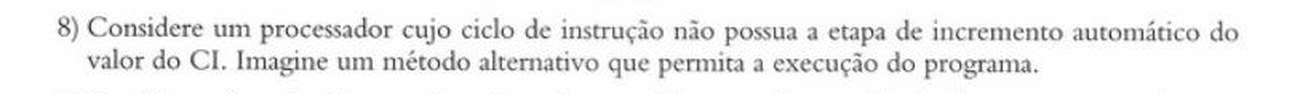

**Resolução**

Sem o incremento automático do CI, o processador não saberia onde está a próxima instrução. **Método alternativo clássico:** incluir no **formato de cada instrução um campo adicional contendo o endereço da próxima instrução** a ser executada (campo "endereço do sucessor"):

```
| C.Op. | operando(s) | endereço da próxima instrução |
```

Ao final da execução, a UC simplesmente carrega o CI (ou diretamente o REM) com o valor desse campo — o sequenciamento deixa de ser implícito (endereços consecutivos) e passa a ser **explícito**, definido instrução a instrução.

Foi assim em máquinas antigas com memória de tambor magnético, em que convinha posicionar a próxima instrução conforme a rotação do tambor. Uma alternativa equivalente seria encerrar cada instrução com um **desvio incondicional explícito** para a seguinte. O custo, em ambos os casos, é o aumento do tamanho das instruções (16 bits a mais por instrução, se os endereços tiverem 16 bits).


---

## Questão 9 — Registrador que controla a sequência de execução

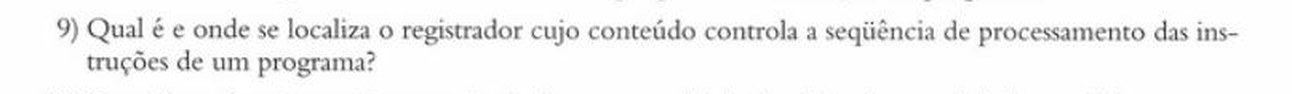

**Resolução**

É o **CI — Contador de Instrução** (em inglês, **PC — Program Counter**), localizado na **área de controle da UCP**, junto à Unidade de Controle.

O CI contém, a cada momento, o **endereço da próxima instrução** a ser buscada na MP. Como no início de cada ciclo seu conteúdo é copiado para o REM (para a busca) e em seguida atualizado — pelo incremento automático ou por uma instrução de desvio, que grava nele um novo endereço — é o seu conteúdo que **determina a sequência** em que as instruções do programa são executadas.


---

## Questão 11 — Registrador que determina a capacidade de memória

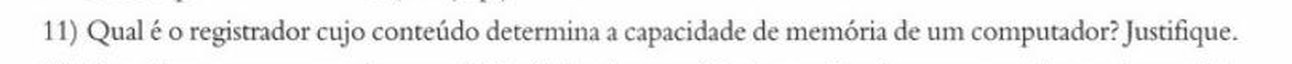

**Resolução**

É o **REM — Registrador de Endereços de Memória** (MAR).

**Justificativa:** todo acesso à MP é feito colocando-se o endereço desejado no REM, que o transfere pelo **barramento de endereços** (ambos com a mesma largura). Se o REM tem **n bits**, ele consegue expressar no máximo

$$2^n \text{ endereços distintos } (0 \text{ a } 2^n - 1)$$

logo a memória **endereçável** não pode ter mais do que 2ⁿ células — ainda que fisicamente se instalasse mais memória, a UCP não teria como referenciá-la. Exemplo: REM de 16 bits → capacidade máxima de 2¹⁶ = 64K células.


---

## Questão 15 — Micro de 8 bits × 16 bits: palavra ou célula?

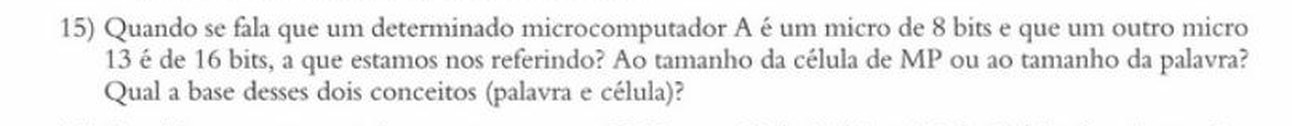

**Resolução**

Estamos nos referindo ao **tamanho da PALAVRA** — não ao da célula.

- **Palavra**: unidade de informação ligada ao **processamento** — corresponde à largura dos registradores de dados e da UAL (em geral também do barramento interno de dados). É a quantidade de bits que o processador busca, armazena e processa "de uma só vez". Micro de 8 bits: palavra de 8 bits; micro de 16 bits: palavra de 16 bits.
- **Célula**: unidade ligada ao **armazenamento/endereçamento** — é o menor conjunto de bits **individualmente endereçável** da MP, praticamente padronizado em **8 bits (1 byte)** em ambos os micros.

**Base dos dois conceitos:** a célula existe para organizar a memória (cada endereço identifica uma célula); a palavra existe para dimensionar o processador (capacidade de manipulação por operação). Por isso um micro de 16 bits continua tendo células de 1 byte — apenas transfere e processa 2 células por vez.


---

## Questão 18 — Processamento sequencial × pipeline

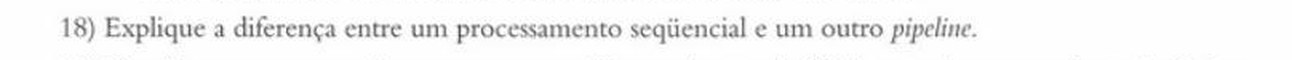

**Resolução**

**Processamento sequencial:** cada instrução percorre **todas** as etapas do ciclo de instrução (busca → decodificação → busca de operandos → execução → armazenamento do resultado) e **só então** a próxima instrução começa. Há uma única instrução em andamento por vez, e os circuitos de cada etapa ficam ociosos na maior parte do tempo.

**Pipeline:** o ciclo de instrução é dividido em **estágios independentes**, cada um realizado por uma unidade própria. Assim que a instrução 1 passa da busca para a decodificação, a busca da instrução 2 já começa, e assim por diante — **várias instruções em andamento simultaneamente, cada uma em um estágio diferente**, como numa linha de montagem.

**Efeito:** o pipeline **não** reduz o tempo de execução de uma instrução isolada (latência), mas aumenta muito a **vazão** (throughput): em regime, conclui-se idealmente uma instrução por ciclo de estágio — com k estágios, ganho teórico próximo de k vezes em relação ao sequencial (na prática, reduzido por dependências e desvios).


---

## Questão 22 — Formato de instrução, campos e acessos à memória

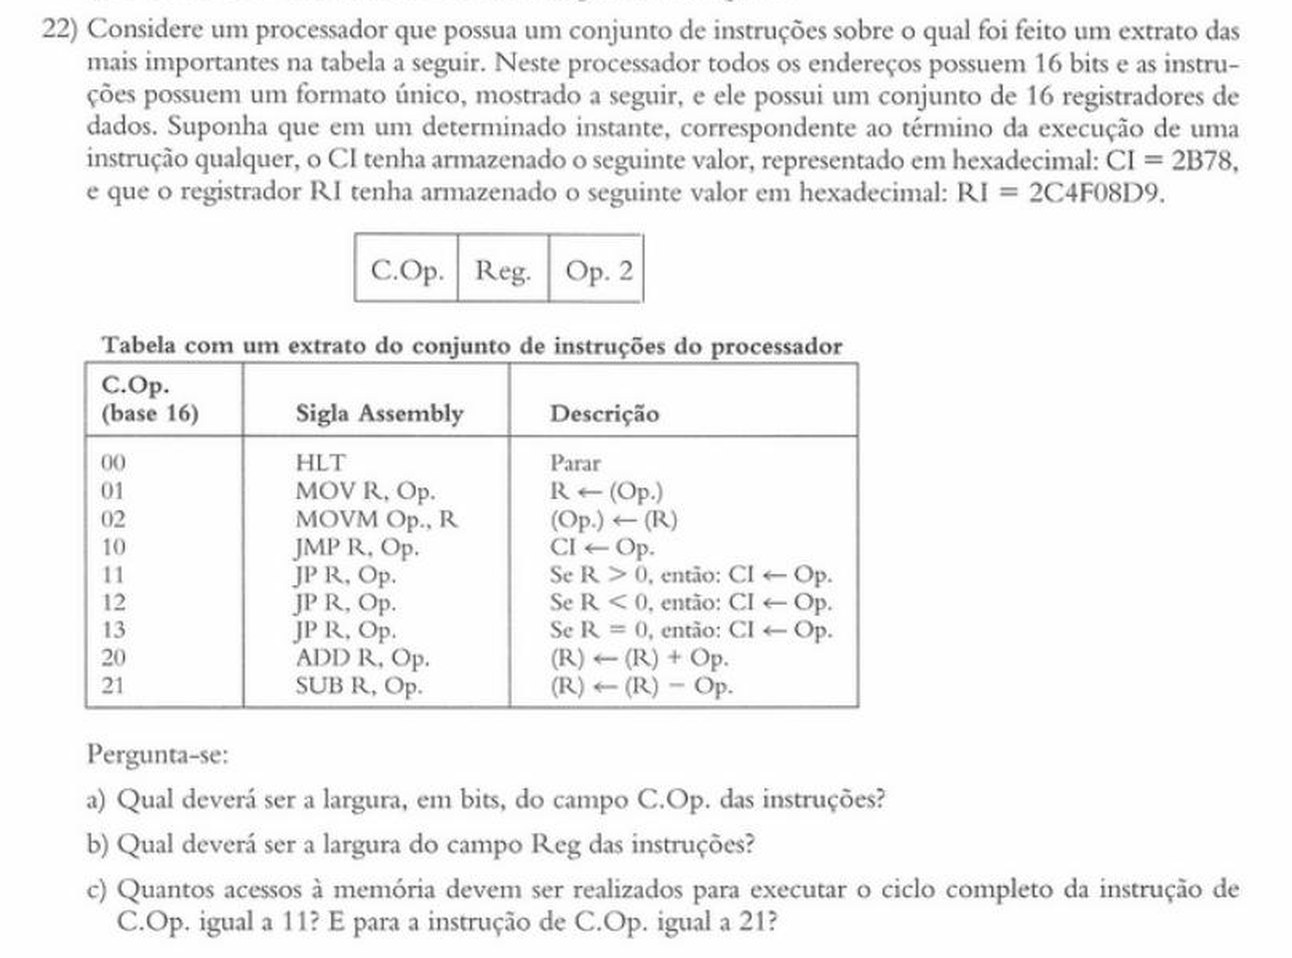

**Resolução**

**Dados extraídos do enunciado:**
- Endereços de **16 bits**; formato único: `| C.Op. | Reg | Op. |`; **4 registradores** de dados;
- RI = 2C01C8₁₆ → o RI guarda a instrução completa, e 6 algarismos hexadecimais = **24 bits** → **cada instrução tem 24 bits**.

---

**a) Largura do campo C.Op.**

$$\underbrace{24}_{\text{instrução}} = C.Op. + \underbrace{2}_{Reg} + \underbrace{16}_{Op.} \;\Rightarrow\; C.Op. = 24 - 2 - 16 = \boxed{6 \text{ bits}}$$

*Verificação:* o maior código do extrato é 21₁₆ = 100001₂, que cabe em 6 bits (com 6 bits o processador pode ter até 2⁶ = 64 instruções — coerente com a tabela ser apenas um "extrato").

**b) Largura do campo Reg**

São 4 registradores de dados; para identificar 1 entre 4:

$$2^{Reg} = 4 \;\Rightarrow\; Reg = \boxed{2 \text{ bits}}$$

**c) Acessos à memória no ciclo completo**

- **C.Op. = 11 (JN R, Op. — desvia se R < 0):** o teste usa um **registrador** e o endereço de desvio **Op. está dentro da própria instrução** (vai direto para o CI, sem consultar a MP). Único acesso necessário: a **busca da instrução** → **1 acesso**.

- **C.Op. = 21 (SUB R, Op. → (R) ← (R) − (Op.)):** além da **busca da instrução** (1 acesso), é preciso **ler o operando (Op.) da memória** (1 acesso). O resultado fica em registrador, sem acesso de escrita → **2 acessos**.


---